## Step 1: Imports

In [2]:
import torch
import transformers
import datasets

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.7.1+cu126
Transformers: 5.15.1
Datasets: 5.0.1
CUDA available: True
GPU: NVIDIA GeForce MX330


## Step 2: Load the sentiment dataset

In [3]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [4]:
print(dataset["train"][0])
print(dataset["train"][1])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [5]:
from collections import Counter

print("Train labels:", Counter(dataset["train"]["label"]))
print("Test labels:", Counter(dataset["test"]["label"]))

Train labels: Counter({0: 12500, 1: 12500})
Test labels: Counter({0: 12500, 1: 12500})


## Step 3: Create train/validation/test splits

In [4]:
# Split the original training set into train and validation
split_dataset = dataset["train"].train_test_split(
    test_size=0.2,
    seed=42,
    stratify_by_column="label"
)

dataset["train"] = split_dataset["train"]
dataset["validation"] = split_dataset["test"]

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 5000
    })
})


In [7]:
from collections import Counter

print("Train:", Counter(dataset["train"]["label"]))
print("Validation:", Counter(dataset["validation"]["label"]))
print("Test:", Counter(dataset["test"]["label"]))

Train: Counter({1: 10000, 0: 10000})
Validation: Counter({0: 2500, 1: 2500})
Test: Counter({0: 12500, 1: 12500})


## Step 4: Clean and tokenize the reviews

In [5]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print(tokenizer)

BertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


In [6]:
import re

def clean_text(example):
    text = re.sub(r"<br\s*/?>", " ", example["text"])
    text = re.sub(r"\s+", " ", text).strip()
    return {"text": text}

dataset = dataset.map(clean_text)

print(dataset["train"][0]["text"][:500])

After reading tons of good reviews about this movie I decided to take it for a spin (I bought it on DVD, hence the "spin" pun...I'm a dork). The beginning was everything I hoped for, a perfect set-up (along with some quotes that I've heard on Various Wu-Tang albums) to what should have been a good movie. But the plot I heard was so great, was so predictable. Every time I saw a character (except for the Lizard) I guessed which Venom he was. Plus, the only cool character gets killed off in the mid


In [7]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

In [8]:
tokenized_dataset = tokenized_dataset.remove_columns(["text"])

print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 50000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5000
    })
})


In [12]:
print(tokenized_dataset["train"][0])

{'label': 1, 'input_ids': [101, 2044, 3752, 6197, 1997, 2204, 4391, 2055, 2023, 3185, 1045, 2787, 2000, 2202, 2009, 2005, 1037, 6714, 1006, 1045, 4149, 2009, 2006, 4966, 1010, 6516, 1996, 1000, 6714, 1000, 26136, 1012, 1012, 1012, 1045, 1005, 1049, 1037, 2079, 8024, 1007, 1012, 1996, 2927, 2001, 2673, 1045, 5113, 2005, 1010, 1037, 3819, 2275, 1011, 2039, 1006, 2247, 2007, 2070, 16614, 2008, 1045, 1005, 2310, 2657, 2006, 2536, 8814, 1011, 9745, 4042, 1007, 2000, 2054, 2323, 2031, 2042, 1037, 2204, 3185, 1012, 2021, 1996, 5436, 1045, 2657, 2001, 2061, 2307, 1010, 2001, 2061, 21425, 1012, 2296, 2051, 1045, 2387, 1037, 2839, 1006, 3272, 2005, 1996, 15450, 1007, 1045, 11445, 2029, 15779, 2002, 2001, 1012, 4606, 1010, 1996, 2069, 4658, 2839, 4152, 2730, 2125, 1999, 1996, 2690, 1997, 1996, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [9]:
tokenized_dataset = tokenized_dataset.remove_columns(["token_type_ids"])

tokenized_dataset.pop("unsupervised")

print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 25000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 5000
    })
})


## Step 5: Load DistilBERT for Sequence Classification

In [14]:
from transformers import AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

print(model)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [15]:
print("Number of labels:", model.config.num_labels)
print("Labels:", model.config.id2label)

Number of labels: 2
Labels: {0: 'LABEL_0', 1: 'LABEL_1'}


In [16]:
model.config.id2label = {
    0: "NEGATIVE",
    1: "POSITIVE"
}

model.config.label2id = {
    "NEGATIVE": 0,
    "POSITIVE": 1
}

print(model.config.id2label)

{0: 'NEGATIVE', 1: 'POSITIVE'}


In [17]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 66,955,010
Trainable parameters: 66,955,010


## Step 6: Configure the training

evaluation metrics:

In [12]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

training arguments:

In [11]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert-imdb",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=2,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)

## Step 6: Create the Trainer

In [20]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

print("Trainer ready.")

Trainer ready.


In [21]:
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")
    print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**2:.1f} MB")

GPU: NVIDIA GeForce MX330
Allocated: 256.5 MB
Reserved:  292.0 MB


In [22]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.320086,0.302370,0.870800,0.864961,0.878800,0.871825
2,0.843734,0.346144,0.875200,0.866980,0.886400,0.876582


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [24]:
save_path = "./distilbert-imdb-final"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model saved to: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./distilbert-imdb-final


## Step 7: Load the saved model and run final test evaluation

In [1]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

save_path = "./distilbert-imdb-final"

tokenizer = AutoTokenizer.from_pretrained(save_path)

model = AutoModelForSequenceClassification.from_pretrained(
    save_path
)

print("Model loaded successfully.")
print(model.config.id2label)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded successfully.
{0: 'NEGATIVE', 1: 'POSITIVE'}


Recreate the Trainer

In [14]:
from transformers import TrainingArguments, Trainer

eval_args = TrainingArguments(
    output_dir="./distilbert-imdb-eval",
    eval_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=eval_args,
    compute_metrics=compute_metrics
)

print("Evaluation trainer ready.")

Evaluation trainer ready.


In [15]:
test_results = trainer.evaluate(
    eval_dataset=tokenized_dataset["test"],
    metric_key_prefix="test"
)

print(test_results)

Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
No log,0.330895,0,0.880400,0.870731,0.893440,0.881940


{'test_loss': 0.33089500665664673, 'test_accuracy': 0.8804, 'test_precision': 0.8707313269920474, 'test_recall': 0.89344, 'test_f1': 0.8819395088051805}


## Step 8: Confusion Matrix

In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions = trainer.predict(tokenized_dataset["test"])

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=-1)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10842  1658]
 [ 1332 11168]]


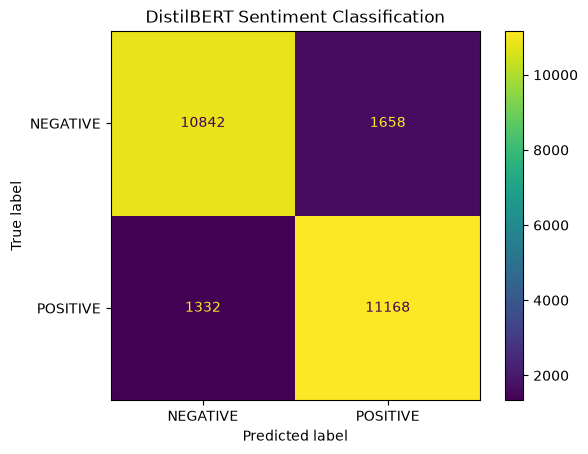

In [17]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NEGATIVE", "POSITIVE"]
)

disp.plot()
plt.title("DistilBERT Sentiment Classification")
plt.show()

## Step 9: Attention Visualization

In [18]:
sample = dataset["test"][0]["text"]
label = dataset["test"][0]["label"]

print("True label:", model.config.id2label[label])
print("\nReview:")
print(sample[:1000])

True label: NEGATIVE

Review:
I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn't match the background, and painfully one-dimensional characters cannot be overcome with a 'sci-fi' setting. (I'm sure there are those of you out there who think Babylon 5 is good sci-fi TV. It's not. It's clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It's really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictable, often painful to watch. The makers of Earth KNOW it's

In [19]:
inputs = tokenizer(
    sample,
    return_tensors="pt",
    truncation=True,
    max_length=128
)

inputs = {
    key: value.to(model.device)
    for key, value in inputs.items()
}

In [28]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    save_path,
    attn_implementation="eager"
)

model.config.output_attentions = True

print("Attention implementation:", model.config._attn_implementation)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Attention implementation: eager


In [30]:
model = model.to("cuda")

In [31]:
inputs = {
    key: value.to(model.device)
    for key, value in inputs.items()
}

In [32]:
model.eval()

with torch.no_grad():
    outputs = model(
        **inputs,
        output_attentions=True
    )

print("Number of attention layers:", len(outputs.attentions))
print("Attention shape:", outputs.attentions[0].shape)

Number of attention layers: 6
Attention shape: torch.Size([1, 12, 128, 128])


## Step 10: Visualize Attention

In [33]:
import matplotlib.pyplot as plt
import numpy as np

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

# Layer 6, Head 1
attention = outputs.attentions[-1][0, 0]

# Attention from [CLS] to every token
cls_attention = attention[0].detach().cpu().numpy()

# Ignore padding tokens
attention_mask = inputs["attention_mask"][0].cpu().numpy()

valid_indices = np.where(attention_mask == 1)[0]

tokens = [tokens[i] for i in valid_indices]
cls_attention = cls_attention[valid_indices]

print("Number of tokens:", len(tokens))
print(list(zip(tokens[:20], cls_attention[:20])))

Number of tokens: 128
[('[CLS]', np.float32(0.013018303)), ('i', np.float32(0.001071539)), ('love', np.float32(0.012293538)), ('sci', np.float32(0.00015554347)), ('-', np.float32(0.0011563535)), ('fi', np.float32(0.0004998867)), ('and', np.float32(0.005053739)), ('am', np.float32(0.0012920051)), ('willing', np.float32(0.0031201427)), ('to', np.float32(0.0002917037)), ('put', np.float32(0.0010209769)), ('up', np.float32(0.00044886107)), ('with', np.float32(0.0001836221)), ('a', np.float32(0.0002237885)), ('lot', np.float32(0.0026165198)), ('.', np.float32(0.0009390761)), ('sci', np.float32(0.00010147482)), ('-', np.float32(0.0005037922)), ('fi', np.float32(9.209276e-05)), ('movies', np.float32(0.0001597084))]


In [34]:
special_tokens = {"[CLS]", "[SEP]", "[PAD]"}

filtered = [
    (token, score)
    for token, score in zip(tokens, cls_attention)
    if token not in special_tokens
]

tokens = [x[0] for x in filtered]
scores = np.array([x[1] for x in filtered])

In [35]:
top_k = 15

top_indices = np.argsort(scores)[-top_k:][::-1]

for i in top_indices:
    print(f"{tokens[i]:15s} {scores[i]:.4f}")

silly           0.2599
and             0.0951
painfully       0.0854
cannot          0.0826
cheap           0.0443
,               0.0396
,               0.0386
,               0.0280
##s             0.0235
tried           0.0234
(               0.0227
-               0.0221
that            0.0195
##ted           0.0194
to              0.0133


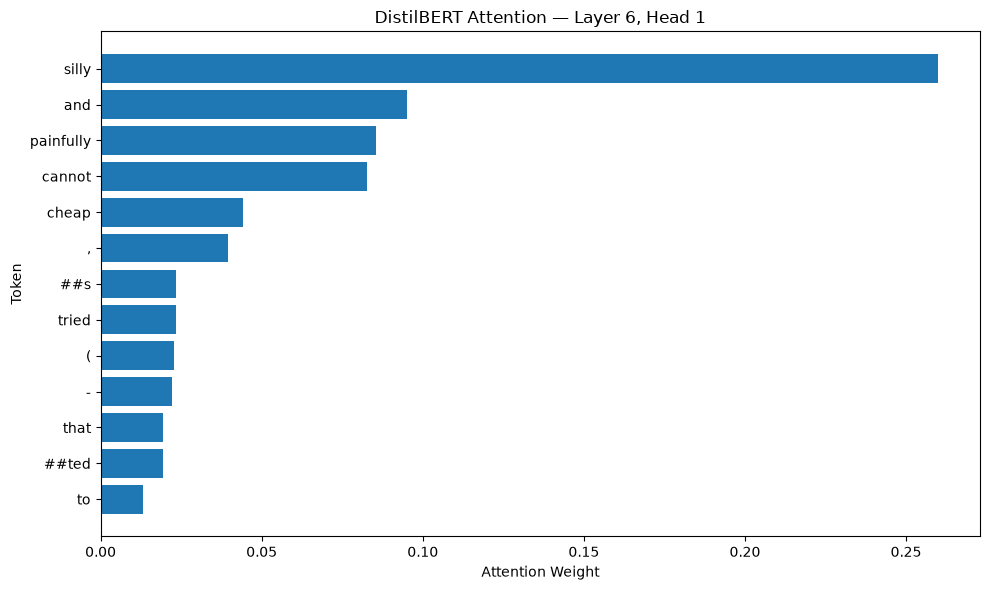

In [36]:
plt.figure(figsize=(10, 6))

plt.barh(
    [tokens[i] for i in top_indices][::-1],
    scores[top_indices][::-1]
)

plt.xlabel("Attention Weight")
plt.ylabel("Token")
plt.title("DistilBERT Attention — Layer 6, Head 1")
plt.tight_layout()
plt.show()

## Step 11: Improve the visualization

In [37]:
from IPython.display import display, HTML

# Normalize attention scores
scores_norm = scores / scores.max()

html = "<div style='font-size:18px; line-height:2.2;'>"

for token, score in zip(tokens, scores_norm):
    # Reconstruct basic WordPiece words
    if token.startswith("##"):
        token = token[2:]
    else:
        token = " " + token

    opacity = 0.15 + (0.85 * float(score))

    html += (
        f"<span style='background-color: rgba(255, 165, 0, {opacity}); "
        f"padding:3px; margin:2px; border-radius:3px;' "
        f"title='Attention: {score:.3f}'>"
        f"{token}</span>"
    )

html += "</div>"

display(HTML(html))

In [40]:
import gradio as gr

print("Gradio version:", gr.__version__)

Gradio version: 6.26.0


## Step 12: Build the Gradio sentiment analyzer

In [41]:
model.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [42]:
def predict_sentiment(text):
    if not text or not text.strip():
        return {"NEGATIVE": 0.0, "POSITIVE": 0.0}

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=-1)[0]

    return {
        "NEGATIVE": float(probabilities[0]),
        "POSITIVE": float(probabilities[1])
    }

In [43]:
demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter a movie review...",
        label="Movie Review"
    ),
    outputs=gr.Label(
        num_top_classes=2,
        label="Sentiment"
    ),
    title="IMDb Sentiment Analyzer",
    description="DistilBERT-based sentiment classification of movie reviews.",
    examples=[
        ["This movie was absolutely fantastic. I loved every minute of it."],
        ["The movie was boring, predictable, and painfully slow."],
        ["It wasn't terrible, but it wasn't particularly good either."]
    ]
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
